# Experiment: Structured Worlds

Four 64×64 dot worlds, named by their control structure:

- **Independent** — 2 independently controlled dots (true dim 4)
- **Coupled** — 1 pair sharing one action (true dim 2)
- **Distractor** — 1 controlled dot + 1 uncontrolled random dot (true dim 2)
- **Combined** — 1 coupled pair + 2 independent + 1 random (true dim 6)

The encoder should recover only the *controllable* degrees of freedom: the PCA
spectrum of the learned latents should show a knee at the true dimensionality.

In [8]:
import sys
from pathlib import Path

CWD = Path(".").resolve()
EXPERIMENT_DIR = CWD if (CWD / "config_2_independent.yaml").exists() \
                 else CWD / "experiments" / "structured_dots"
REPO_ROOT = EXPERIMENT_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from misc.plot_style import FULL_WIDTH, HALF_WIDTH, palette, apply_matplotlib_style, figure_size
apply_matplotlib_style()

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

from datasets.structured_dot_world import (
    StructuredDotWorldDataset, StructuredDotWorldConfig,
    DotGroup, MotionType, DEFAULT_PALETTE,
)

RUNS = [
    "2_independent",
    "1_coupled_pair",
    "1_dot_1_random",
    "combined",
]
RESULTS_DIR = EXPERIMENT_DIR / "results"

results = {}
for run in RUNS:
    run_dir = RESULTS_DIR / run
    if run_dir.exists():
        results[run] = {
            "history":    torch.load(run_dir / "train_history.pt", map_location="cpu", weights_only=False),
            "embeddings": torch.load(run_dir / "embeddings.pt",    map_location="cpu", weights_only=False),
        }
        with open(run_dir / "config.yaml") as f:
            results[run]["cfg"] = yaml.safe_load(f)
        print(f"  loaded {run}")
    else:
        print(f"  [missing] {run}")

HAS_RESULTS = len(results) > 0
SMOOTH_W = 5

  loaded 2_independent
  loaded 1_coupled_pair
  loaded 1_dot_1_random
  loaded combined


In [10]:
def to_numpy(x):
    return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def smooth(v, w=SMOOTH_W):
    return pd.Series(np.asarray(v, dtype=float)).rolling(w, min_periods=1).mean().to_numpy()

def pca_eigvals(Z, eps=1e-12):
    Zc = Z - Z.mean(axis=0)
    _, S, _ = np.linalg.svd(Zc, full_matrices=False)
    return np.maximum((S ** 2) / max(1, Z.shape[0] - 1), eps)

def effective_rank(eigvals, eps=1e-12):
    e = eigvals[eigvals > eps]
    if e.size == 0: return 1.0
    p = e / e.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

def snapshot_metrics(snap):
    Z = np.concatenate([to_numpy(snap["z_t"]), to_numpy(snap["z_tp1"])], axis=0)
    ev = pca_eigvals(Z)
    return {
        "z_l2":       float(np.linalg.norm(Z, axis=1).mean()),
        "z_std":      float(Z.std(axis=0, ddof=0).mean()),
        "z_eff_rank": effective_rank(ev),
        "mean_z_l2":  float(np.linalg.norm(Z.mean(axis=0))),
        "eigvals":    ev,
    }

if HAS_RESULTS:
    metrics = {}
    for run, data in results.items():
        metrics[run] = {
            int(e): snapshot_metrics(s)
            for e, s in data["embeddings"]["snapshots"].items()
        }

In [11]:
# Per-setting world configs, short names, controllable ("true") latent dim, colors.
def _auto_colors(n, offset=0):
    return list(range(offset, offset + n))

SETTING_CONFIGS = {
    "2_independent": StructuredDotWorldConfig(groups=[
        DotGroup(MotionType.INDEPENDENT, 2, _auto_colors(2, 0)),
    ]),
    "1_coupled_pair": StructuredDotWorldConfig(groups=[
        DotGroup(MotionType.COUPLED, 2, _auto_colors(2, 0)),
    ]),
    "1_dot_1_random": StructuredDotWorldConfig(groups=[
        DotGroup(MotionType.INDEPENDENT, 1, _auto_colors(1, 0)),
        DotGroup(MotionType.RANDOM,      1, _auto_colors(1, 1)),
    ]),
    "combined": StructuredDotWorldConfig(groups=[
        DotGroup(MotionType.COUPLED,      2, _auto_colors(2, 0)),
        DotGroup(MotionType.INDEPENDENT,  2, _auto_colors(2, 2)),
        DotGroup(MotionType.RANDOM,       1, _auto_colors(1, 4)),
    ]),
}

TITLES = {
    "2_independent":  "Independent",
    "1_coupled_pair": "Coupled",
    "1_dot_1_random": "Distractor",
    "combined":       "Combined",
}

TRUE_LATENT_DIM = {"2_independent": 4, "1_coupled_pair": 2, "1_dot_1_random": 2, "combined": 6}

RUN_COLOR = {
    "2_independent":  palette["Dark Blue"],
    "1_coupled_pair": palette["Dark Red"],
    "1_dot_1_random": palette["Med Purple"],
    "combined":       palette["Dark Grey"],
}


def render_world(ax, run, seed=7, n=40):
    """Show one rendered observation (just the dots) for a setting."""
    ds = StructuredDotWorldDataset(config=SETTING_CONFIGS[run], num_samples=n, seed=seed)
    best_idx, best = 0, -1.0
    for i in range(len(ds)):                       # pick the least-cluttered sample
        pts = ds[i][3].numpy().reshape(-1, 2)
        if len(pts) < 2:
            best_idx = i; break
        d = min(np.linalg.norm(pts[a] - pts[b])
                for a in range(len(pts)) for b in range(a + 1, len(pts)))
        if d > best:
            best, best_idx = d, i
    ax.imshow(ds[best_idx][0].numpy().transpose(1, 2, 0), interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])

## Loss Curves

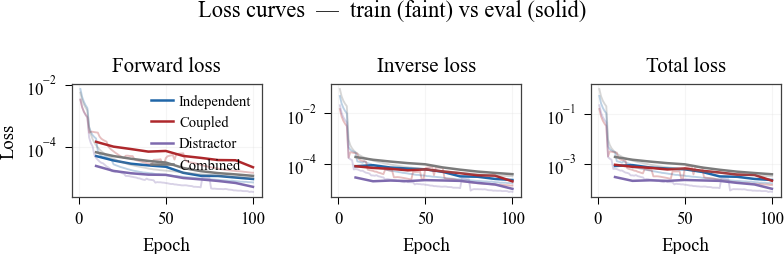

In [12]:
if not HAS_RESULTS:
    print("No results found. Run train.py first.")
else:
    runs = [r for r in RUNS if r in results]
    fig, axes = plt.subplots(1, 3, figsize=figure_size(FULL_WIDTH, ratio=0.34))
    for ax, key, title in zip(axes, ["fwd", "inv", "total"], ["Forward", "Inverse", "Total"]):
        for run in runs:
            tr, ev = results[run]["history"]["train"], results[run]["history"]["eval"]
            ax.semilogy(tr["epoch"], smooth(tr[key]), color=RUN_COLOR[run], alpha=0.3, linewidth=0.9)
            ax.semilogy(ev["epoch"], smooth(ev[key]), color=RUN_COLOR[run], label=TITLES[run])
        ax.set_title(f"{title} loss")
        ax.set_xlabel("Epoch")
        ax.grid(True, which="both", alpha=0.3)
    axes[0].set_ylabel("Loss")
    axes[0].legend(frameon=False, fontsize=7)
    fig.suptitle("Loss curves  —  train (faint) vs eval (solid)")
    fig.tight_layout()
    plt.show()

## Latent Geometry

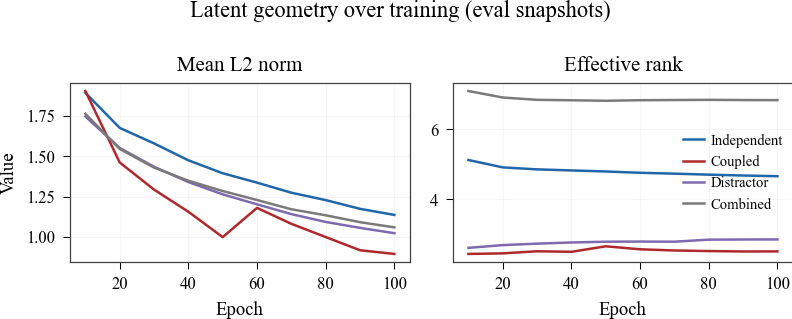

In [13]:
if not HAS_RESULTS:
    print("No results found.")
else:
    specs = [("z_l2", "Mean L2 norm"), ("z_eff_rank", "Effective rank")]
    fig, axes = plt.subplots(1, 2, figsize=figure_size(FULL_WIDTH, ratio=0.42))
    for ax, (key, title) in zip(axes, specs):
        for run in RUNS:
            if run not in metrics:
                continue
            epochs = sorted(metrics[run])
            ax.plot(epochs, [metrics[run][e][key] for e in epochs],
                    color=RUN_COLOR[run], label=TITLES[run])
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("Value")
    axes[1].legend(frameon=False, fontsize=7)
    fig.suptitle("Latent geometry over training (eval snapshots)")
    fig.tight_layout()
    plt.show()

## World settings and final PCA spectra

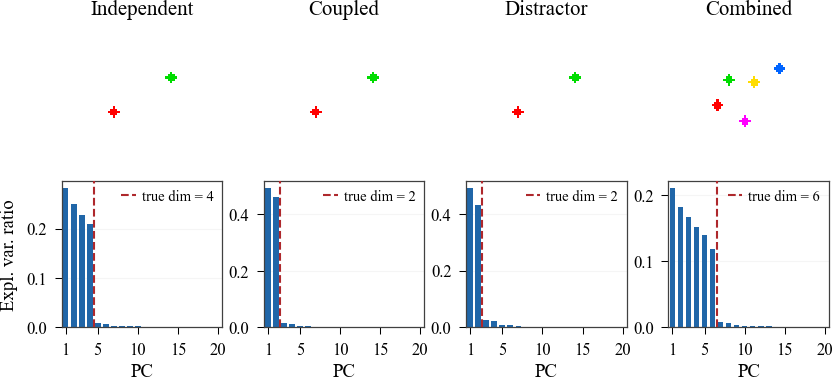

In [14]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# Paper figure: world settings (just the dots) on top, final PCA spectra below.
PC_CUTOFF = 20

if not HAS_RESULTS:
    print("No results found.")
else:
    runs = [r for r in RUNS if r in metrics]
    fig = plt.figure(figsize=figure_size(FULL_WIDTH, height=2.6))
    gs = gridspec.GridSpec(2, len(runs), figure=fig, height_ratios=[1.0, 1.0],
                           hspace=0.1, wspace=0.26,
                           left=0.06, right=0.99, bottom=0.14, top=0.93)

    for col, run in enumerate(runs):
        ax = fig.add_subplot(gs[0, col])           # row 0: rendered world (dots only)
        render_world(ax, run)
        ax.set_title(TITLES[run], pad=2)
        for s in ax.spines.values():
            s.set_visible(False)

        ax = fig.add_subplot(gs[1, col])           # row 1: PCA spectrum + true dim marker
        last = max(metrics[run])
        evr = metrics[run][last]["eigvals"]
        evr = evr / np.maximum(evr.sum(), 1e-12)
        n_show = min(PC_CUTOFF, len(evr))
        ax.bar(np.arange(1, n_show + 1), evr[:n_show], color=palette["Dark Blue"], width=0.7, zorder=2)
        ax.axvline(TRUE_LATENT_DIM[run] + 0.5, color=palette["Dark Red"], lw=1.0, ls="--", zorder=3)
        ax.legend(handles=[Line2D([0], [0], color=palette["Dark Red"], ls="--", lw=1.0,
                                  label=f"true dim = {TRUE_LATENT_DIM[run]}")],
                  loc="upper right", frameon=False, fontsize=7, handlelength=1, borderaxespad=0.2)
        ax.set_xlim(0.5, PC_CUTOFF + 0.5)
        ax.set_xlabel("PC", labelpad=2)
        ax.set_xticks([1, 5, 10, 15, 20])
        ax.grid(True, axis="y", alpha=0.3)
        ax.set_axisbelow(True)
        if col == 0:
            ax.set_ylabel("Expl. var. ratio")

    plt.show()